In [214]:
# 引入本次實驗所需模組
import numpy as np
import matplotlib.pyplot as plt

In [215]:
# 建立空間座標
N = 2048           # 取樣點
L = 100            # 空間範圍

x = np.linspace(-L/2, L/2, N)
dx = x[1] - x[0]

In [216]:
# 定義 Gaussian Wave Packet 函數
def gaussian_wave_packet(x, sigma, k0):
    
    envelope = np.exp(-x**2/(2*sigma**2)) # 高斯狀的包絡線
    # bug:缺少虛數，無法表示相位 
    # carrier = np.exp(k0*x) # 內部正弦波

    # fix
    carrier = np.exp(1j*k0*x) # 內部正弦波
    psi = envelope * carrier # 波函數
    
    return psi

# 產生波包
## 設定：
sigma = 5      # 空間寬度 Δx
k0 = 5         # 中心波數
## 生成：
psi = gaussian_wave_packet(x, sigma, k0)

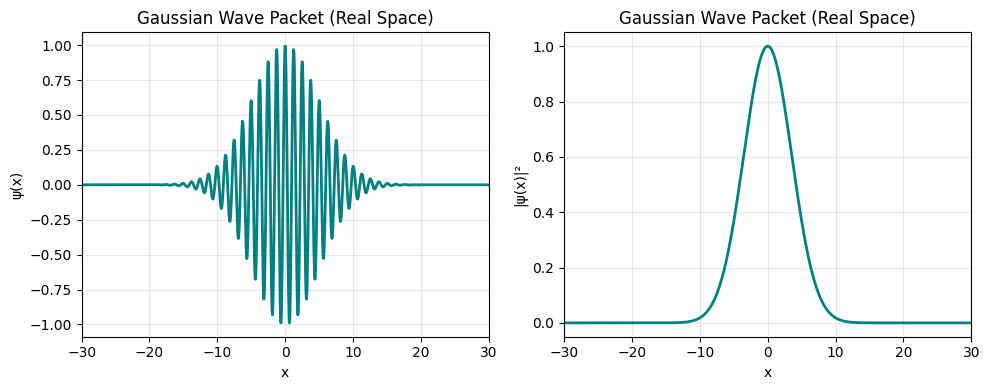

In [217]:
# 畫實空間波包
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(x, psi, color="teal", linewidth=2, label="Gaussian Wave Packet")
plt.xlim(-30, 30)
plt.xlabel("x")
plt.ylabel("ψ(x)")
plt.title("Gaussian Wave Packet (Real Space)")
plt.grid(True, alpha=0.3)

plt.subplot(1,2,2)
plt.plot(x, np.abs(psi)**2, color="teal", linewidth=2, label="Gaussian Wave Packet")
plt.xlim(-30, 30)
plt.xlabel("x")
plt.ylabel("|ψ(x)|²")
plt.title("Gaussian Wave Packet (Real Space)")
plt.grid(True, alpha=0.3)

plt.tight_layout() # 自動調整子圖之間的間距，避免重疊
plt.show()

# Q: 波函數的絕對值平方表示什麼？
# A: 絕對值平方代表了機率密度，這就是「波恩定則」

In [218]:
# FFT 轉到 k-space
psi_k = np.fft.fft(psi)
psi_k = np.fft.fftshift(psi_k)

# 建立 k 軸：
k = np.fft.fftfreq(N, d=dx) * 2*np.pi
k = np.fft.fftshift(k)

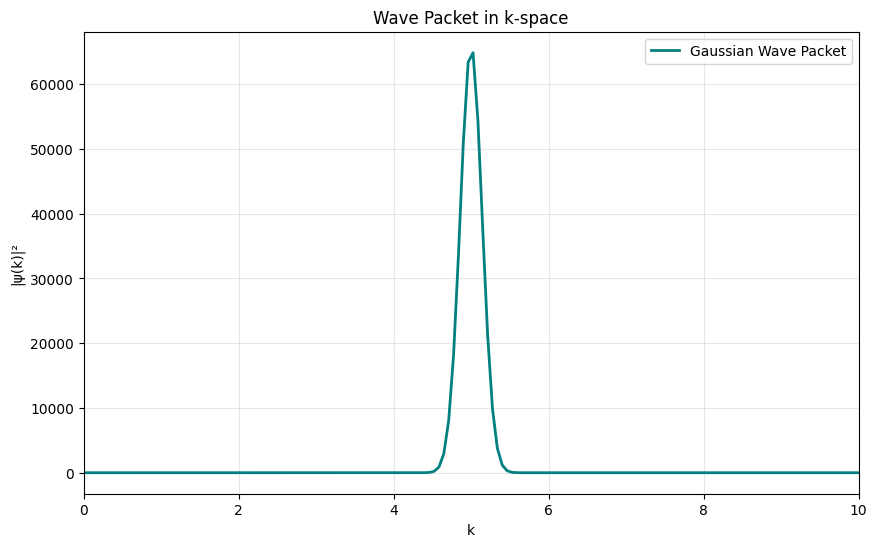

In [219]:
# 畫 k-space 波包
plt.figure(figsize=(10,6))
plt.plot(k, np.abs(psi_k)**2, color="teal", linewidth=2, label="Gaussian Wave Packet")
plt.xlim(0, 10)
plt.xlabel("k")
plt.ylabel("|ψ(k)|²")
plt.title("Wave Packet in k-space")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [220]:
# 改變 Δx 觀察 Δk
sigma = 10
psi = gaussian_wave_packet(x, sigma, k0) 
psi_k = np.fft.fftshift(np.fft.fft(psi))

# 自變數
# 生成高斯波包
## x:實空間中的位置座標
## sigma:高斯波包的標準差，決定波包在實空間中的寬度
## k0:波包的中心波數，決定波包的振盪頻率
# 計算動量空間中的波包
## np.fft.fft:對波包 psi 執行快速傅立葉變換，將波包從實空間轉換到動量空間 (k-space)。
## np.fft.fftshift:將傅立葉變換的結果重新排列，使零頻率分量位於中心（方便繪圖）。

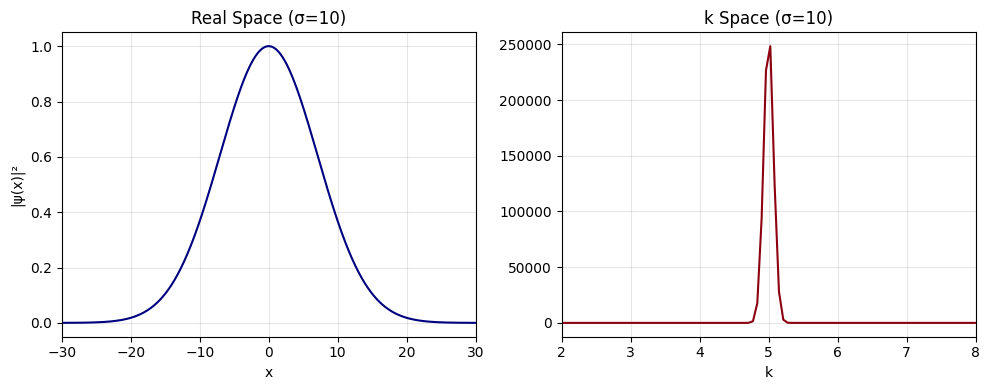

In [221]:
# 畫ㄍ比較圖
plt.figure(figsize=(10,4))
# 子圖一：實空間中的波包
plt.subplot(1,2,1)
plt.plot(x, np.abs(psi)**2, color="navy", linewidth=1.5)
plt.xlim(-30, 30)
plt.title(f"Real Space (σ={sigma})")
plt.xlabel("x")
plt.ylabel("|ψ(x)|²")
plt.grid(True, alpha=0.3)
# 子圖二：動量空間空間中的波包
plt.subplot(1,2,2)
plt.plot(k, np.abs(psi_k)**2, color="#8C000F", linewidth=1.5)
plt.xlim(2, 8)
plt.title(f"k Space (σ={sigma})")
plt.xlabel("k")
plt.grid(True, alpha=0.3)

plt.tight_layout() # 自動調整子圖之間的間距，避免重疊
plt.show()

當高斯波包在實空間變得更窄 (Δx 減小) 時，其 Fourier transform 在 k 空間變得更寬 (Δk 增大)。這反映了 Fourier transform 的基本性質:

 ΔxΔk ≈ constant

 並對應到量子力學中的海森堡測不準原理:
 
 ΔxΔp ≥ ħ/2

思考點 2 (互補性/測不準原理)：

如果一個電子被侷限在極小的空間中 (例如原子核附近)，它的動量 (與 k 
有關) 分佈會發生什麼事？這是否意味著它的動能會很高？

ANS:

1.對高斯波包，$\Delta x \Delta k \approx \frac{1}{2}$，所以當空間(Δx)極小，Δk必變得極大，而根據動量與波數關係：
$$𝑝=ℏ𝑘$$
可以看出，物理意義就是粒子的動量分布變得極寬，也就是說動量不確定度極大。

2.根據動量與動能關係式：
$$E=\frac{p^2}{2m}$$
可以看出，因為$E \propto p^2$，當動量分布變寬，包含了較大的p，平均動能就會上升。

思考點 3 (波的疏密)： 

當 k 值很大時，代表實空間中的波紋是呈現「密集」還是「稀疏」的狀態？

ANS:

根據波數與波長關係：
$$k=\frac{2\pi}{\lambda}$$
可知，當k值很大時，波長很小，表示波紋呈現密集狀態。